<a href="https://colab.research.google.com/github/etooooooooo/Gruppo-1--Data-Science/blob/Ale-branch/analisi_credit_default.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Previsione dell'insolvenza creditizia — Credit Card Default

**Corso:** Introduzione al Pensiero Computazionale e alla Data Science (a.a. 2025/26)

**Gruppo N. 1 :** Monopoli Alessandro 1232093, Giuliana Ponissi «aggiungi badge», Miriam cota 1216760

**Obiettivo:** prevedere se un cliente sarà insolvente (*default*) sul pagamento della carta di credito nel mese successivo, a partire da caratteristiche demografiche, limite di credito e storico dei pagamenti.

Il notebook segue le fasi indicate nelle specifiche di progetto:
1. descrizione e comprensione del dataset
2. analisi esplorativa e visualizzazione
3. modellazione (3 modelli: regressione logistica, k-NN, Random Forest)
4. valutazione e interpretazione dei risultati

> **Nota sull'uso di assistenti LLM:** per la stesura di questo notebook è stato utilizzato un assistente LLM (Claude) come supporto alla programmazione e all'organizzazione del lavoro. Tutto il codice è stato rivisto, compreso e commentato dai membri del gruppo.

## Fase 1. Setup e caricamento dei dati

Importiamo le librerie viste a lezione: `pandas` per i dati tabellari, `seaborn` e `matplotlib` per i grafici, `scikit-learn` per i modelli di machine learning.

Il file CSV ha una particolarità: contiene **due righe di intestazione** (la prima con i codici X1–X23, la seconda con i nomi reali delle variabili). Usiamo `header=1` per leggere la seconda riga come intestazione.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, precision_score,
                             recall_score, f1_score)

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

df = pd.read_csv("sample_data/Credit_Card_Default.csv", header=1)
# rinominiamo il target con un nome più comodo
df = df.rename(columns={"default payment next month": "DEFAULT"})
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


Ogni riga rappresenta un cliente. Le variabili principali (dal file di descrizione):

- `LIMIT_BAL`: credito concesso (dollari taiwanesi, NT$)
- `SEX` (1 = uomo, 2 = donna), `EDUCATION` (1 = post-laurea, 2 = università, 3 = superiori, 4 = altro), `MARRIAGE` (1 = sposato, 2 = single, 3 = altro), `AGE` (anni)
- `PAY_0` … `PAY_6`: stato dei pagamenti da settembre (PAY_0) ad aprile (PAY_6); -1 = pagato puntualmente, 1 = ritardo di un mese, 2 = ritardo di due mesi, ecc.
- `BILL_AMT1` … `BILL_AMT6`: importo dell'estratto conto da settembre ad aprile
- `PAY_AMT1` … `PAY_AMT6`: importo pagato da settembre ad aprile
- `DEFAULT`: variabile target (1 = insolvente il mese successivo, 0 = solvente)

## Fase 2 — Descrizione e comprensione del dataset

In questa fase rispondiamo a una serie di domande sulla struttura, qualità e limiti dei dati.

### Domanda 2.1 — Quante osservazioni e quante variabili contiene il dataset? Di che tipo sono?

In [ ]:
print("Dimensioni (righe, colonne):", df.shape)
df.info()

Dimensioni (righe, colonne): (30000, 25)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   ID         30000 non-null  int64
 1   LIMIT_BAL  30000 non-null  int64
 2   SEX        30000 non-null  int64
 3   EDUCATION  30000 non-null  int64
 4   MARRIAGE   30000 non-null  int64
 5   AGE        30000 non-null  int64
 6   PAY_0      30000 non-null  int64
 7   PAY_2      30000 non-null  int64
 8   PAY_3      30000 non-null  int64
 9   PAY_4      30000 non-null  int64
 10  PAY_5      30000 non-null  int64
 11  PAY_6      30000 non-null  int64
 12  BILL_AMT1  30000 non-null  int64
 13  BILL_AMT2  30000 non-null  int64
 14  BILL_AMT3  30000 non-null  int64
 15  BILL_AMT4  30000 non-null  int64
 16  BILL_AMT5  30000 non-null  int64
 17  BILL_AMT6  30000 non-null  int64
 18  PAY_AMT1   30000 non-null  int64
 19  PAY_AMT2   30000 non-null  int64
 20  PAY_AMT3 

**Risposta:** il dataset contiene **30.000 clienti** e **25 colonne** (l'identificativo `ID`, 23 variabili esplicative e il target `DEFAULT`). Tutte le variabili sono di tipo intero: anche quelle concettualmente categoriche (`SEX`, `EDUCATION`, `MARRIAGE`) sono codificate con numeri.

### Domanda 2.2 — Ci sono valori mancanti o righe duplicate?

In [ ]:
print("Valori mancanti totali:", df.isnull().sum().sum())
print("ID duplicati:", df["ID"].duplicated().sum())
print("Righe interamente duplicate (escluso ID):", df.drop(columns="ID").duplicated().sum())

Valori mancanti totali: 0
ID duplicati: 0
Righe interamente duplicate (escluso ID): 35


**Risposta:** non ci sono valori mancanti né ID duplicati. Esistono alcune righe identiche su tutte le variabili (clienti diversi con stessi valori): essendo poche su 30.000 e plausibili (es. clienti inattivi con tutti zero), le manteniamo.

### Domanda 2.3 — Come è distribuita la variabile target? Le classi sono bilanciate?

In [ ]:
print(df["DEFAULT"].value_counts())
print()
print(df["DEFAULT"].value_counts(normalize=True).round(3))

DEFAULT
0    23364
1     6636
Name: count, dtype: int64

DEFAULT
0    0.779
1    0.221
Name: proportion, dtype: float64


**Risposta:** il **22,1%** dei clienti risulta insolvente, il 77,9% no.

> ⚠️ **Riflessione critica 1 — class imbalance:** le classi sono sbilanciate (circa 1 insolvente ogni 4 solventi). Un modello banale che predice sempre "non insolvente" otterrebbe già il 77,9% di accuracy: questo valore va quindi usato come *baseline* e l'accuracy da sola non basta per valutare i modelli. Serviranno precision, recall e f1-score sulla classe minoritaria.

### Domanda 2.4 — Quali valori assumono le principali variabili numeriche? (statistiche descrittive)

In [ ]:
df[["LIMIT_BAL", "AGE", "BILL_AMT1", "PAY_AMT1"]].describe().round(1)

,LIMIT_BAL,AGE,BILL_AMT1,PAY_AMT1
count,30000.0,30000.0,30000.0,30000.0
mean,167484.3,35.5,51223.3,5663.6
std,129747.7,9.2,73635.9,16563.3
min,10000.0,21.0,-165580.0,0.0
25%,50000.0,28.0,3558.8,1000.0
50%,140000.0,34.0,22381.5,2100.0
75%,240000.0,41.0,67091.0,5006.0
max,1000000.0,79.0,964511.0,873552.0


**Risposta:** il limite di credito mediano è 140.000 NT$ con forte asimmetria (media 167.484 > mediana; max 1.000.000). L'età va da 21 a 79 anni (mediana 34). Gli importi di fatturazione e pagamento hanno code lunghissime: `PAY_AMT1` ha mediana 2.100 ma massimo 873.552.

### Domanda 2.5 — I valori delle variabili categoriche sono coerenti con la documentazione?

In [ ]:
for col in ["SEX", "EDUCATION", "MARRIAGE"]:
    print(col, "->", df[col].value_counts().sort_index().to_dict())

SEX -> {1: 11888, 2: 18112}
EDUCATION -> {0: 14, 1: 10585, 2: 14030, 3: 4917, 4: 123, 5: 280, 6: 51}
MARRIAGE -> {0: 54, 1: 13659, 2: 15964, 3: 323}


**Risposta:** `SEX` è coerente (1, 2). **`EDUCATION` contiene i valori 0, 5 e 6** e **`MARRIAGE` contiene il valore 0**, che **non sono documentati** nel file di descrizione.

> ⚠️ **Riflessione critica 2 — valori non documentati:** 0, 5 e 6 in `EDUCATION` (468 casi) e 0 in `MARRIAGE` (54 casi) non hanno significato noto. Ipotesi ragionevole: si tratta di codifiche residue o dati non dichiarati. Decisione: li accorpiamo nella categoria "altro" (4 per EDUCATION, 3 per MARRIAGE), documentando la scelta.

### Domanda 2.6 — Quali valori assumono le variabili di stato pagamento PAY_*?

In [ ]:
pay_cols = ["PAY_" + str(n) for n in [0, 2, 3, 4, 5, 6]]

tabella = pd.concat(
    [df[col].value_counts() for col in pay_cols],
    axis=1,
    keys=pay_cols
).sort_index().fillna(0).astype(int)

print(tabella)

    PAY_0  PAY_2  PAY_3  PAY_4  PAY_5  PAY_6
-2   2759   3782   4085   4348   4546   4895
-1   5686   6050   5938   5687   5539   5740
 0  14737  15730  15764  16455  16947  16286
 1   3688     28      4      2      0      0
 2   2667   3927   3819   3159   2626   2766
 3    322    326    240    180    178    184
 4     76     99     76     69     84     49
 5     26     25     21     35     17     13
 6     11     12     23      5      4     19
 7      9     20     27     58     58     46
 8     19      1      3      2      1      2


**Risposta:** oltre ai valori documentati (-1 = puntuale, 1...9 = mesi di ritardo), compaiono **-2** e **0**, che insieme coprono la maggioranza delle osservazioni.

> ⚠️ **Riflessione critica 3 — scala ambigua di PAY_*:** -2 e 0 non sono documentati. Confrontandoli con gli importi fatturati, un'interpretazione diffusa (e coerente con i dati) è: **-2 = nessun consumo nel mese**, **0 = uso della carta con pagamento minimo (credito revolving)**. Manteniamo questi valori così come sono, trattando PAY_* come scala ordinale di "gravità del ritardo".

### Domanda 2.7 — Ci sono outlier o valori anomali negli importi?

In [ ]:
neg_bill = (df[[f"BILL_AMT{i}" for i in range(1, 7)]] < 0).sum().sum()
print("Valori negativi nelle colonne BILL_AMT:", neg_bill)
df[[f"BILL_AMT{i}" for i in range(1, 7)]].describe().round(0)

Valori negativi nelle colonne BILL_AMT: 3932


,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6
count,30000.0,30000.0,30000.0,30000.0,30000.0,30000.0
mean,51223.0,49179.0,47013.0,43263.0,40311.0,38872.0
std,73636.0,71174.0,69349.0,64333.0,60797.0,59554.0
min,-165580.0,-69777.0,-157264.0,-170000.0,-81334.0,-339603.0
25%,3559.0,2985.0,2666.0,2327.0,1763.0,1256.0
50%,22382.0,21200.0,20088.0,19052.0,18104.0,17071.0
75%,67091.0,64006.0,60165.0,54506.0,50190.0,49198.0
max,964511.0,983931.0,1664089.0,891586.0,927171.0,961664.0


**Risposta:** esistono migliaia di **estratti conto negativi** (fino a -339.603 NT$): non sono errori, ma situazioni in cui il cliente ha pagato più del dovuto (saldo a credito). Le distribuzioni hanno inoltre outlier estremi sulla coda destra (max ~960.000 contro mediana ~20.000). Modelli basati sulle distanze (k-NN) saranno sensibili a queste scale: servirà la **standardizzazione**.

### Domanda 2.8 — Le variabili BILL_AMT sono ridondanti tra loro?

In [ ]:
bill_corr = df[[f"BILL_AMT{i}" for i in range(1, 7)]].corr()
print(bill_corr.round(2))

           BILL_AMT1  BILL_AMT2  BILL_AMT3  BILL_AMT4  BILL_AMT5  BILL_AMT6
BILL_AMT1       1.00       0.95       0.89       0.86       0.83       0.80
BILL_AMT2       0.95       1.00       0.93       0.89       0.86       0.83
BILL_AMT3       0.89       0.93       1.00       0.92       0.88       0.85
BILL_AMT4       0.86       0.89       0.92       1.00       0.94       0.90
BILL_AMT5       0.83       0.86       0.88       0.94       1.00       0.95
BILL_AMT6       0.80       0.83       0.85       0.90       0.95       1.00


**Risposta:** le sei variabili `BILL_AMT` sono **fortemente correlate fra loro** (r tra 0,80 e 0,95): l'estratto conto di un mese è molto simile a quello del mese successivo. C'è quindi ridondanza informativa: per modelli lineari i coefficienti delle singole BILL_AMT andranno interpretati con cautela (multicollinearità).

### Pulizia dei dati

Sulla base delle risposte precedenti applichiamo le decisioni prese: accorpiamo i valori non documentati di `EDUCATION` e `MARRIAGE` nella categoria "altro".

In [ ]:
df["EDUCATION"] = df["EDUCATION"].replace({0: 4, 5: 4, 6: 4})
df["MARRIAGE"] = df["MARRIAGE"].replace({0: 3})
print("EDUCATION:", df["EDUCATION"].value_counts().sort_index().to_dict())
print("MARRIAGE:", df["MARRIAGE"].value_counts().sort_index().to_dict())

EDUCATION: {1: 10585, 2: 14030, 3: 4917, 4: 468}
MARRIAGE: {1: 13659, 2: 15964, 3: 377}


## Fase 3 — Analisi esplorativa e visualizzazione

Studiamo le relazioni fra le feature e il target con grafici di tipo diverso (boxplot, barplot, heatmap, istogramma).

### Domanda 3.1 — I clienti insolventi hanno un limite di credito più basso? (confronto tra gruppi n. 1)

**Ipotesi:** la banca concede limiti più alti ai clienti più affidabili, quindi ci aspettiamo `LIMIT_BAL` più basso fra gli insolventi.

FileNotFoundError: [Errno 2] No such file or directory: '../figures/boxplot_limit_bal.png'

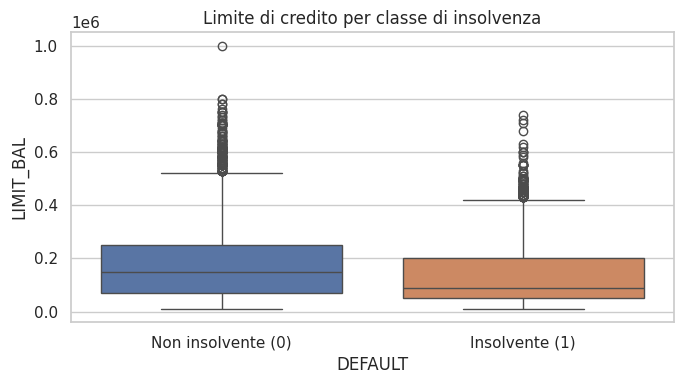

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=df, x="DEFAULT", y="LIMIT_BAL", hue="DEFAULT", legend=False, ax=ax)
ax.set_xticks([0, 1])
ax.set_xticklabels(["Non insolvente (0)", "Insolvente (1)"])
ax.set_title("Limite di credito per classe di insolvenza")
plt.tight_layout()
plt.savefig("../figures/boxplot_limit_bal.png", dpi=150)
plt.show()

print(df.groupby("DEFAULT")["LIMIT_BAL"].median())

**Risposta:** l'ipotesi è confermata: la mediana del limite di credito è **150.000 NT$ per i solventi contro 90.000 NT$ per gli insolventi**. Il limite di credito è quindi informativo, pur con molta sovrapposizione tra le distribuzioni.

### Domanda 3.2 — Lo stato del pagamento più recente (PAY_0) è associato al default?

**Ipotesi:** chi è già in ritardo a settembre ha probabilità molto più alta di essere insolvente il mese successivo.

FileNotFoundError: [Errno 2] No such file or directory: '../figures/barplot_pay0.png'

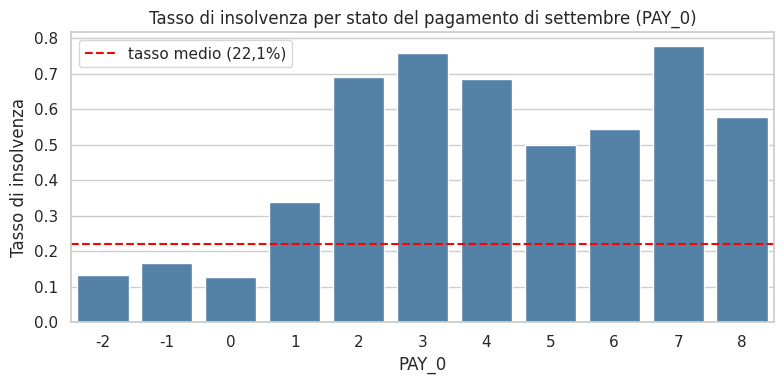

In [ ]:
tasso = df.groupby("PAY_0")["DEFAULT"].mean().reset_index()
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=tasso, x="PAY_0", y="DEFAULT", color="steelblue", ax=ax)
ax.axhline(df["DEFAULT"].mean(), color="red", linestyle="--", label="tasso medio (22,1%)")
ax.set_ylabel("Tasso di insolvenza")
ax.set_title("Tasso di insolvenza per stato del pagamento di settembre (PAY_0)")
ax.legend()
plt.tight_layout()
plt.savefig("../figures/barplot_pay0.png", dpi=150)
plt.show()

**Risposta:** la relazione è fortissima e monotona: il tasso di insolvenza passa da ~13% per chi non ha ritardi (-2, -1, 0) a **~70% per chi ha 2 mesi di ritardo**, e resta sopra il 50% per ritardi maggiori. `PAY_0` si candida a essere la feature più predittiva.

### Domanda 3.3 — Quali variabili sono più correlate con il target?

**Ipotesi:** le variabili di ritardo (PAY_*) sono più correlate con il default rispetto a quelle demografiche.

In [ ]:
cols = ["LIMIT_BAL", "AGE", "PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6",
        "BILL_AMT1", "PAY_AMT1", "PAY_AMT2", "DEFAULT"]
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(df[cols].corr(), annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, ax=ax)
ax.set_title("Matrice di correlazione (selezione di variabili)")
plt.tight_layout()
plt.savefig("../figures/heatmap_correlazioni.png", dpi=150)
plt.show()

**Risposta:** l'ipotesi è confermata. Le correlazioni più alte con `DEFAULT` sono quelle delle variabili **PAY_*** (PAY_0: r ≈ 0,32, decrescente man mano che si va indietro nel tempo), seguite da `LIMIT_BAL` (r ≈ -0,15, negativa: più credito, meno default). `AGE` e gli importi fatturati sono quasi scorrelati con il target. Si nota anche la forte correlazione fra le PAY_* consecutive: chi è in ritardo un mese tende a esserlo anche il successivo.

### Domanda 3.4 — L'età distingue i clienti insolventi? (confronto tra gruppi n. 2)

**Ipotesi:** i clienti più giovani, con minore stabilità economica, sono più a rischio.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(data=df, x="AGE", hue="DEFAULT", stat="density",
             common_norm=False, element="step", bins=30, ax=axes[0])
axes[0].set_title("Distribuzione dell'età per classe")

df["fascia_eta"] = pd.cut(df["AGE"], bins=[20, 30, 40, 50, 60, 80],
                          labels=["21-30", "31-40", "41-50", "51-60", "61+"])
tasso_eta = df.groupby("fascia_eta", observed=True)["DEFAULT"].mean().reset_index()
sns.barplot(data=tasso_eta, x="fascia_eta", y="DEFAULT", color="steelblue", ax=axes[1])
axes[1].axhline(df["DEFAULT"].mean(), color="red", linestyle="--")
axes[1].set_ylabel("Tasso di insolvenza")
axes[1].set_title("Tasso di insolvenza per fascia d'età")
plt.tight_layout()
plt.savefig("../figures/eta_default.png", dpi=150)
plt.show()

print(tasso_eta.round(3))